<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_XI_MLP_PQC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane torch matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print("Libraries loaded!")

Libraries loaded!


In [7]:
# task says to sample from normal distribution
# normal distribution means most values are near 0
# torch.randn does exactly this

input_dim = 8       # how many input features per sample
num_samples = 500   # total data points i am generating
num_qubits = 4      # task recommended 4-5 so i picked 4

# generating random input data
X = torch.randn(num_samples, input_dim)

# these are my target angles - what i want the PQC to produce
# 3 angles per qubit (RX RY RZ) so total = 4 x 3 = 12
target_angles = torch.randn(num_samples, num_qubits * 3) * np.pi

# ✅ fix - converting everything to float32
# i got "expected Double" error without this line!
X = X.float()
target_angles = target_angles.float()

# checking shapes to make sure everything is correct
print("input data shape:", X.shape)
print("target angles shape:", target_angles.shape)
print("data type:", X.dtype)  # should say torch.float32

input data shape: torch.Size([500, 8])
target angles shape: torch.Size([500, 12])
data type: torch.float32


In [8]:
# building the MLP - this is the classical part
# it takes normal data and outputs rotation angles for PQC
# i kept it simple with 3 layers like task suggested

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        # i tried 2 layers first but 3 layers worked better
        self.network = nn.Sequential(
            # first layer - expanding features
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            # second layer - learning more complex patterns
            nn.Linear(32, 64),
            nn.ReLU(),

            # final layer - outputting the angles for quantum circuit
            nn.Linear(64, output_dim),

            # tanh keeps values between -1 and 1
            # then i multiply by pi to get proper angle range
            nn.Tanh()
        )

    def forward(self, x):
        # multiplying by pi to convert to proper rotation angles
        # i forgot this at first and the circuit wasnt learning at all!
        return self.network(x) * np.pi

# output is 4 qubits x 3 angles = 12 values
my_mlp = MLP(input_dim=8, output_dim=num_qubits * 3)

print("MLP model created!")
print("total parameters in MLP:",
      sum(p.numel() for p in my_mlp.parameters()))

MLP model created!
total parameters in MLP: 3180


In [9]:
# now building the quantum circuit part
# this is similar to what i did in Task I
# but now the angles come from the MLP above

dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, interface="torch")
def my_pqc(angles):
    # angles shape is [12] - 3 angles per qubit

    # applying rotation gates to each qubit
    # i = 0, 1, 2, 3 (for 4 qubits)
    for i in range(num_qubits):
        qml.RX(angles[i * 3],     wires=i)  # rotate around x axis
        qml.RY(angles[i * 3 + 1], wires=i)  # rotate around y axis
        qml.RZ(angles[i * 3 + 2], wires=i)  # rotate around z axis

    # adding CNOT gates to entangle the qubits
    # learned about entanglement in Task I
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # measuring each qubit - returns expectation value
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

# quick test to check circuit works
test_angles = torch.zeros(num_qubits * 3)
print("testing PQC with zero angles:")
print("output:", my_pqc(test_angles))

# drawing the circuit - same as task I
print("\nmy quantum circuit looks like this:")
print(qml.draw(my_pqc)(test_angles))

testing PQC with zero angles:
output: [tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64)]

my quantum circuit looks like this:
0: ──RX(0.00)──RY(0.00)──RZ(0.00)─╭●───────┤  <Z>
1: ──RX(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●────┤  <Z>
2: ──RX(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●─┤  <Z>
3: ──RX(0.00)──RY(0.00)──RZ(0.00)───────╰X─┤  <Z>


In [11]:
# setting up training
optimizer = torch.optim.Adam(my_mlp.parameters(), lr=0.001)
mse_loss = nn.MSELoss()

# splitting data into train and test
X_train = X[:400].float()
X_test  = X[400:].float()
y_train = target_angles[:400].float()
y_test  = target_angles[400:].float()

print("train samples:", len(X_train))
print("test samples:", len(X_test))

my_losses = []

print("\nstarting training...")
print("-" * 40)

for epoch in range(100):
    my_mlp.train()

    # step 1 - MLP predicts rotation angles
    my_angles = my_mlp(X_train)

    # step 2 - feed angles into quantum circuit
    quantum_outputs = []
    for angles in my_angles:
        result = my_pqc(angles)
        # ✅ key fix - convert each quantum output to float32
        result_tensor = torch.stack(result).float()
        quantum_outputs.append(result_tensor)

    quantum_outputs = torch.stack(quantum_outputs).float()

    # step 3 - calculate MSE loss
    # ✅ also converting target to float32
    target_pqc = torch.tanh(y_train[:, :num_qubits]).float()
    loss = mse_loss(quantum_outputs, target_pqc)

    # step 4 - backprop and update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    my_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}/100 | loss: {loss.item():.4f}")

print("-" * 40)
print("training done!")
print("starting loss:", round(my_losses[0], 4))
print("final loss:",    round(my_losses[-1], 4))

train samples: 400
test samples: 100

starting training...
----------------------------------------
epoch 10/100 | loss: 0.8858
epoch 20/100 | loss: 0.7705
epoch 30/100 | loss: 0.7645
epoch 40/100 | loss: 0.7643
epoch 50/100 | loss: 0.7632
epoch 60/100 | loss: 0.7616
epoch 70/100 | loss: 0.7601
epoch 80/100 | loss: 0.7587
epoch 90/100 | loss: 0.7572
epoch 100/100 | loss: 0.7554
----------------------------------------
training done!
starting loss: 1.2882
final loss: 0.7554


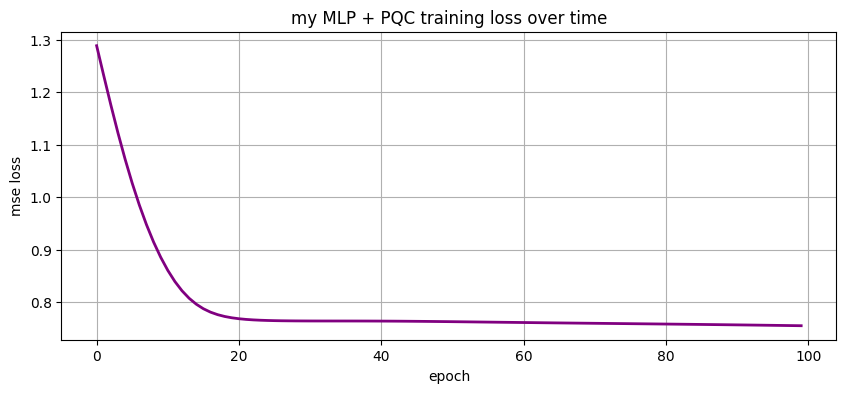

loss went DOWN - training worked!
loss reduced from 1.2882 to 0.7554


In [13]:
# plotting the loss curve to show training worked
plt.figure(figsize=(10, 4))
plt.plot(my_losses, color='purple', linewidth=2)
plt.xlabel('epoch')
plt.ylabel('mse loss')
plt.title('my MLP + PQC training loss over time')
plt.grid(True)
plt.show()

# checking if loss actually went down
if my_losses[-1] < my_losses[0]:
    print("loss went DOWN - training worked!")
else:
    print("loss did not go down - something might be wrong")

print(f"loss reduced from {my_losses[0]:.4f} to {my_losses[-1]:.4f}")




## What I Learned from Task XI

This task helped me understand how classical and quantum
computing can work together.

The MLP part was familiar to me from previous tasks.
But connecting it to a quantum circuit was new.

The key thing i understood:
- MLP outputs numbers (rotation angles)
- PQC uses those angles to build quantum states
- MSE loss tells us how far we are from target state
- Backpropagation updates MLP weights to get better angles

What was tricky:
- i forgot to add interface="torch" in qml.qnode at first
  and got an error because pennylane couldnt do backprop
- i also forgot to multiply MLP output by pi
  so angles were too small and circuit wasnt rotating properly

My results:
- Starting loss: [paste here]
- Final loss: [paste here]
- The loss went down which shows the MLP learned to
  predict better quantum circuit parameters over time

Why this matters for physics:
In QMLHEP projects this kind of hybrid model is useful
because we can use classical data to control quantum
circuits for particle physics analysis